# West Des Moines, Iowa: PDSI Resampling (2022-2025)
**Data Source:** gridMET (4 km resolution)  
**Process:** Resampling high-resolution pentad (5-day) data into monthly averages.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd

# 1. GitHub Data Link
# Data fetched from: https://app.climateengine.org/climateEngine
data_url = 'https://raw.githubusercontent.com/alhelibrito/Terra_Project/main/pentads_pdsi_wdm_2022_2025.csv'

# 2. Data Loading and Cleaning
df = pd.read_csv(data_url, skiprows=1, names=['date', 'pdsi'])
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['date'])
df.set_index('date', inplace=True)
df['pdsi'] = pd.to_numeric(df['pdsi'], errors='coerce')

# 3. Display Raw 5-Day Data (Pentads)
print("Original 5-Day Data (Pentads):")
print(df.head(10))

Original 5-Day Data (Pentads):
            pdsi
date            
2022-05-01 -1.53
2022-10-01 -1.55
2022-04-02 -1.20
2022-09-02 -1.18
2022-01-03 -1.55
2022-06-03 -1.51
2022-11-03 -1.46
2022-05-04 -1.05
2022-10-04 -1.02
2022-05-05 -0.89


### Monthly Resampling
Monthly PDSI averages were calculated by **resampling** 5-day pentad data into **monthly arithmetic means**. This process effectively smooths short-term fluctuations into a standardized climate trend, facilitating comparison with other monthly environmental variables.

In [7]:
# 4. Monthly Resampling
df_monthly = df['pdsi'].resample('MS').mean().to_frame()

# 5. Display Monthly Averages
print("\nProcessed Monthly PDSI Averages:")
print(df_monthly.head(12))


Processed Monthly PDSI Averages:
                pdsi
date                
2022-01-01 -2.346667
2022-02-01 -2.275000
2022-03-01 -1.950000
2022-04-01 -1.126667
2022-05-01 -1.156667
2022-06-01 -2.363333
2022-07-01 -2.290000
2022-08-01 -2.120000
2022-09-01 -1.153333
2022-10-01 -1.136667
2022-11-01 -2.356667
2022-12-01 -2.290000


In [8]:
# 6. Export processed monthly data to CSV
# 'index=True' ensures the monthly dates are included in the file
df_monthly.to_csv('monthly_pdsi_wdm_2022_2025.csv', index=True)

print("Success: 'monthly_pdsi_wdm_2022_2025.csv' generated.")

Success: 'monthly_pdsi_wdm_2022_2025.csv' generated.


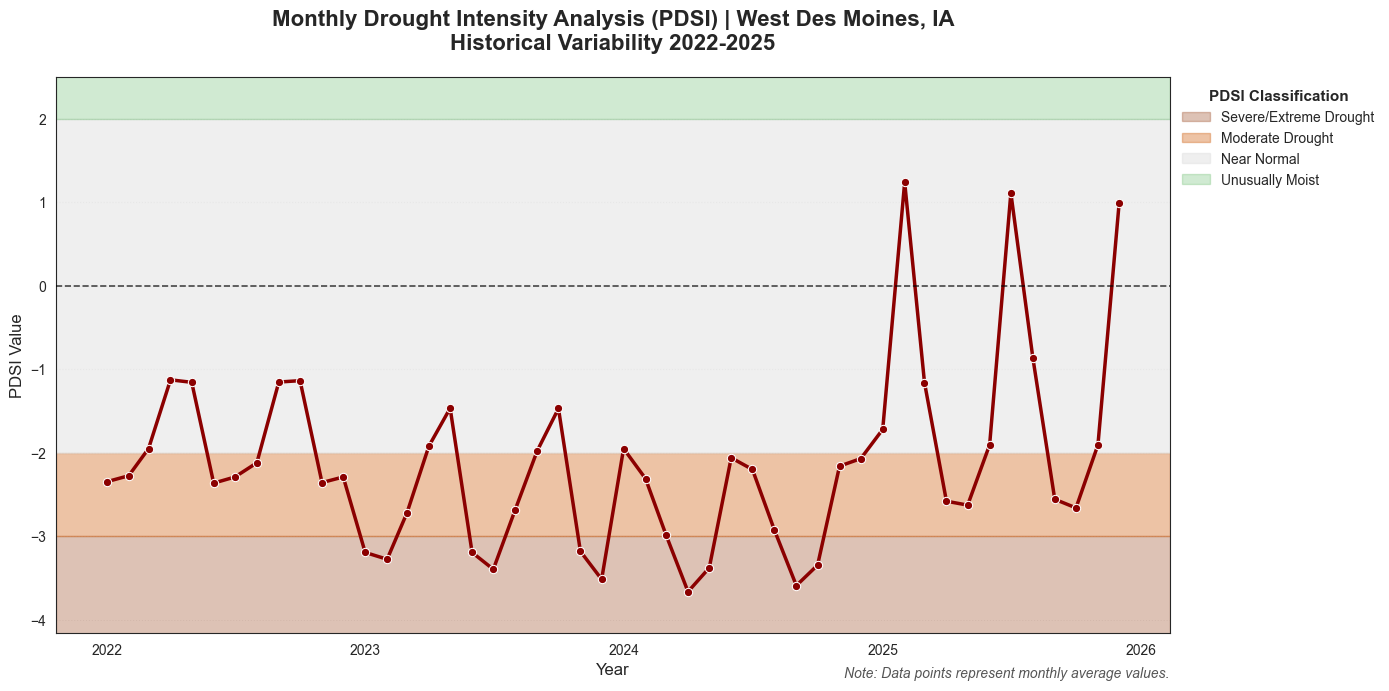

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Configuration
plt.figure(figsize=(14, 7))
sns.set_style("white")

# 1. Base Plot (Monthly Data)
ax = sns.lineplot(data=df_monthly, x=df_monthly.index, y='pdsi', 
                 marker='o', color='darkred', linewidth=2.5, zorder=5)

# 2. HIGH-CONTRAST PDSI CLASSIFICATION BANDS
plt.axhspan(-10, -3, color='#A0522D', alpha=0.35, label='Severe/Extreme Drought')
plt.axhspan(-3, -2, color='#D2691E', alpha=0.4, label='Moderate Drought')
plt.axhspan(-2, 2, color='#E0E0E0', alpha=0.5, label='Near Normal')
plt.axhspan(2, 10, color='#66BB6A', alpha=0.3, label='Unusually Moist')

# 3. Reference Line (Zero)
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7, zorder=6)

# 4. X-Axis Formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator()) # Añade marcas pequeñas para cada mes

# 5. International Labels and Title (Updated with 'Monthly')
plt.title('Monthly Drought Intensity Analysis (PDSI) | West Des Moines, IA\nHistorical Variability 2022-2025', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('PDSI Value', fontsize=12)

# Y-Axis limits
plt.ylim(df_monthly['pdsi'].min() - 0.5, 2.5)

# 6. Legend
leg = plt.legend(title='PDSI Classification', loc='upper left', bbox_to_anchor=(1, 1), 
                 frameon=False, fontsize=10)
plt.setp(leg.get_title(), fontsize=11, fontweight='bold')

# 7. ADDING THE MONTHLY NOTE (Bottom right)
plt.text(1, -0.08, 'Note: Data points represent monthly average values.', 
         transform=ax.transAxes, ha='right', fontsize=10, style='italic', color='#555555')

plt.grid(True, axis='y', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.savefig('Monthly PDSI analysis.png', bbox_inches='tight')
plt.show()